In [ ]:
import os, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,precision_score, recall_score)
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("data/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print(df.head())
print(df["qua_mon"].value_counts())
print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1
qua_mon
1    71
0    49
Name: count, dtype: int64
Ty le qua mon: 0.5917
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}   {sigmoid(z):.4f}")

print()
for z in [1.0, 2.5, 3.7]:
    print(f"z = {z}: {sigmoid(-z):.6f} va {1 - sigmoid(z):.6f}")

print()
w, b = 0.4, -5.0
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"{gio:5.1f}   {z:6.2f}   {sigmoid(z):.4f}")

 -6   0.0025
 -4   0.0180
 -2   0.1192
 -1   0.2689
  0   0.5000
  1   0.7311
  2   0.8808
  4   0.9820
  6   0.9975

z = 1.0: 0.268941 va 0.268941
z = 2.5: 0.075858 va 0.075858
z = 3.7: 0.024127 va 0.024127

  5.0    -3.00   0.0474
 10.0    -1.00   0.2689
 12.5     0.00   0.5000
 15.0     1.00   0.7311
 20.0     3.00   0.9526
 25.0     5.00   0.9933


In [ ]:
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])
print(f"w = {w:.6f}, b = {b:.6f}")
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"{gio:5.1f}   {p:.4f}   {n}")

w = 0.392819, b = -5.064890
So gio on ung voi xac suat 0.5: 12.89 gio
  5.0   0.0431   0
 10.0   0.2429   0
 13.0   0.5104   1
 20.0   0.9422   1
 28.0   0.9974   1


In [ ]:
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
print("Hoc:", len(X_train), "| Kiem tra:", len(X_test))

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")

Hoc: 90 | Kiem tra: 30
TN = 9, FP = 3, FN = 1, TP = 17
Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947


In [ ]:
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong  So_bi_doan_qua  Precision  Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred_t, zero_division=1)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    print(f"  {nguong:.1f}      {y_pred_t.sum():3d}          {pre:.4f}    {rec:.4f}")

Nguong  So_bi_doan_qua  Precision  Recall
  0.2       24          0.7500    1.0000
  0.3       20          0.8500    0.9444
  0.4       20          0.8500    0.9444
  0.5       20          0.8500    0.9444
  0.6       16          1.0000    0.8889
  0.7       15          1.0000    0.8333
  0.8       13          1.0000    0.7222


In [ ]:
for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    m = LogisticRegression().fit(X_train, y_train)
    print(f"{ten}: accuracy = {accuracy_score(y_test, m.predict(X_test)):.4f}")

X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
m = LogisticRegression().fit(X_train, y_train)
for ten_cot, he_so in zip(X.columns, m.coef_[0]):
    print(f"{ten_cot:14s} {he_so:+.4f}")
print(f"{'he so chan':14s} {m.intercept_[0]:+.4f}")

Mot bien: accuracy = 0.8667
Hai bien: accuracy = 0.9000
gio_on         +0.3035
diem_giua_ky   +0.5885
he so chan     -6.9811


#Bài tập

###Bài 1


In [ ]:
nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_con_lai = df[df["diem_giua_ky"] < 7]

print("So ban co diem giua ky >= 7:", len(nhom_cao))
print("Ty le qua mon nhom >= 7    :", round(nhom_cao["qua_mon"].mean(), 4))
print("Ty le qua mon nhom con lai :", round(nhom_con_lai["qua_mon"].mean(), 4))

So ban co diem giua ky >= 7: 31
Ty le qua mon nhom >= 7    : 0.9032
Ty le qua mon nhom con lai : 0.4831


###Bài 2

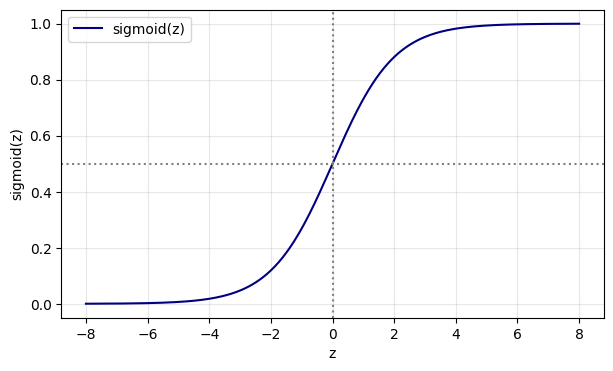

In [ ]:
z = np.linspace(-8, 8, 400)
s = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, s, color="navy", label="sigmoid(z)")
plt.axhline(0.5, color="gray", linestyle=":")
plt.axvline(0, color="gray", linestyle=":")
plt.xlabel("z"); plt.ylabel("sigmoid(z)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()

###Bài 3


In [ ]:
mo_hinh = LogisticRegression().fit(df[["gio_on"]], df["qua_mon"])
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    xac_suat = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"gio = {gio:5.2f}  z = {z:7.3f}  xac suat = {xac_suat:.4f}  nhan = {nhan}")

for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

gio =  3.00  z =  -3.886  xac suat = 0.0201  nhan = 0
gio =  8.00  z =  -1.922  xac suat = 0.1276  nhan = 0
gio = 12.89  z =  -0.001  xac suat = 0.4996  nhan = 0
gio = 18.00  z =   2.006  xac suat = 0.8814  nhan = 1
gio = 26.00  z =   5.148  xac suat = 0.9942  nhan = 1


###Bài 4

In [ ]:
X = df[["gio_on"]]; y = df["qua_mon"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
y_pred = LogisticRegression().fit(X_train, y_train).predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1        = {f1:.4f}")

TP = 17, TN = 9, FP = 3, FN = 1
Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947


###Bài 5

In [ ]:
p = LogisticRegression().fit(X_train, y_train).predict_proba(X_test)[:, 1]

tot_nhat, f1_tot_nhat = None, -1
print("Nguong     F1")
for nguong in np.arange(0.05, 1.0, 0.05):
    f1 = f1_score(y_test, (p >= nguong).astype(int), zero_division=0)
    print(f"  {nguong:.2f}   {f1:.4f}")
    if f1 > f1_tot_nhat:
        tot_nhat, f1_tot_nhat = nguong, f1

print(f"\nNguong cho F1 cao nhat: {tot_nhat:.2f} (F1 = {f1_tot_nhat:.4f})")

Nguong     F1
  0.05   0.7826
  0.10   0.8182
  0.15   0.8182
  0.20   0.8571
  0.25   0.9000
  0.30   0.8947
  0.35   0.8947
  0.40   0.8947
  0.45   0.8947
  0.50   0.8947
  0.55   0.8889
  0.60   0.9412
  0.65   0.9412
  0.70   0.9091
  0.75   0.8750
  0.80   0.8387
  0.85   0.8000
  0.90   0.5600
  0.95   0.4348

Nguong cho F1 cao nhat: 0.60 (F1 = 0.9412)


###Bài 6

                                                           

In [ ]:
for lop, ten in [(1, "lop qua mon"), (0, "lop rot mon")]:
    pre = precision_score(y_test, y_pred, pos_label=lop)
    rec = recall_score(y_test, y_pred, pos_label=lop)
    print(f"{ten:12s}: precision = {pre:.4f}, recall = {rec:.4f}")

lop qua mon : precision = 0.8500, recall = 0.9444
lop rot mon : precision = 0.9000, recall = 0.7500
